In [ ]:
iPhone-11-pro-max-price-regression

In [37]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/ebay_iphone_11_pro_max.csv")


cleaning and pre-processing.

In [53]:
# Block 2: Clean the 'Price' column
def clean_price(price):
    # Remove '$' and spaces
    price = str(price).replace('$', '').strip()

    # If it's a range like '467.95 to 568.95', return the mean
    if 'to' in price:
        try:
            parts = price.split('to')
            parts = [float(p.strip()) for p in parts]
            return np.mean(parts)
        except:
            return np.nan # Handle badly formatted ranges
    else:
        try:
            return float(price)
        except:
            return np.nan # Handle invalid entries

df['Price'] = df['Price'].apply(clean_price)
df = df.dropna(subset=['Price'])

# Display head after cleaning
df.head()


,Title,Price,Storage,Color,Condition,Lock_Status
0,NEW LISTINGApple iPhone 11 Pro Max(A2161) 64GB...,310.25,64.0,Gray,New,Unlocked
1,Apple iPhone 11 Pro Max (A2161) 64GB Space Gra...,361.25,64.0,Gray,Unknown,Unlocked
2,Apple iPhone 11 PRO MAX 64GB 256GB 512GB (UNLO...,518.45,64.0,Other,Unknown,Unknown
3,NEW LISTINGApple iPhone 11 Pro Max(A2161) 64GB...,306.00,64.0,Gray,New,Unlocked
4,Apple iPhone 11 Pro Max - 256GB - Gold (Unlock...,300.00,256.0,Gold,Unknown,Unlocked


Extract useful features from Title

In [54]:
# Block 3: Extract Features from 'Title' (Standardized to LOWERCASE)
def extract_storage(title):
    # This remains the same as it extracts a number
    match = re.search(r'(\d+)\s?GB', title)
    return int(match.group(1)) if match else np.nan

def extract_color(title):
    # All search terms and return values are lowercase
    colors = ['gold', 'silver', 'green', 'gray', 'graphite', 'midnight']
    for color in colors:
        if color in title.lower():
            return color
    return 'other'

def extract_condition(title):
    # Searches are case-insensitive, but return value is lowercase
    title_upper = title.upper()
    if 'NEW' in title_upper:
        return 'new'
    elif 'REFURBISHED' in title_upper:
        return 'refurbished'
    elif 'USED' in title_upper:
        return 'used'
    else:
        # This will catch everything else, including "excellent" or "fair"
        return 'unknown'

def extract_lock(title):
    # Returns 'unlocked', 'locked', or 'unknown' (all lowercase)
    title_lower = title.lower()
    if 'unlocked' in title_lower:
        return 'unlocked'
    elif 'locked' in title_lower:
        # Note: If a title is ambiguous, it should map to 'unknown' or 'locked'
        # based on context. We'll stick to 'locked' for explicit inclusion.
        return 'locked'
    else:
        return 'unknown'

df['Storage'] = df['Title'].apply(extract_storage)
df['Color'] = df['Title'].apply(extract_color)
df['Condition'] = df['Title'].apply(extract_condition)
df['Lock_Status'] = df['Title'].apply(extract_lock)

# Drop rows with missing storage
df = df.dropna(subset=['Storage'])

# Display head after cleaning
df.head()

,Title,Price,Storage,Color,Condition,Lock_Status
0,NEW LISTINGApple iPhone 11 Pro Max(A2161) 64GB...,310.25,64,gray,new,unlocked
1,Apple iPhone 11 Pro Max (A2161) 64GB Space Gra...,361.25,64,gray,unknown,unlocked
2,Apple iPhone 11 PRO MAX 64GB 256GB 512GB (UNLO...,518.45,64,other,unknown,unlocked
3,NEW LISTINGApple iPhone 11 Pro Max(A2161) 64GB...,306.00,64,gray,new,unlocked
4,Apple iPhone 11 Pro Max - 256GB - Gold (Unlock...,300.00,256,gold,unknown,unlocked


Split data into train and test sets.

In [55]:
# Block 4: Split Data
X = df[['Storage', 'Color', 'Condition', 'Lock_Status']]
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the split shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (144, 4)
y_train shape: (144,)


Build pipelines    (Linear and Ridge Regression)

In [56]:
# Block 5: Create column transformer for preprocessing (ROBUST)
numeric_features = ['Storage']
categorical_features = ['Color', 'Condition', 'Lock_Status']

numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    # **CRITICAL FIX**: handle_unknown='ignore' ensures the pipeline won't crash
    # if it sees a color or condition not present in the training data.
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Note: The preprocessor must be fitted in the next step (Block 6 or 7)
# before it can be used for prediction.
print("Preprocessor pipeline created with robust OneHotEncoder setting.")

Preprocessor pipeline created with robust OneHotEncoder setting.


Train linear regression

In [57]:
# Block 6: Linear Regression
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results:")
print(f"Mean Squared Error: {mse_linear:.2f}")
print(f"R² Score: {r2_linear:.3f}")

# The results are:
# Mean Squared Error: 12331.66
# R² Score: -0.224

Linear Regression Results:
Mean Squared Error: 12331.66
R² Score: -0.224


Train rigid regression

In [58]:
# Block 7: Ridge Regression
ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))  # lambda = 1
])

# Fit the model using the robust preprocessor
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("\nRidge Regression Results:")
print(f"Mean Squared Error: {mse_ridge:.2f}")
print(f"R² Score: {r2_ridge:.3f}")


Ridge Regression Results:
Mean Squared Error: 10254.34
R² Score: -0.018


Compare performances.

In [73]:
# Block 8: Compare
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression'],
    'MSE': [mse_linear, mse_ridge],
    'R²': [r2_linear, r2_ridge]
})
print(results)

               Model           MSE        R²
0  Linear Regression  12331.657576 -0.223805
1   Ridge Regression  10254.344475 -0.017651


Plot feature importances

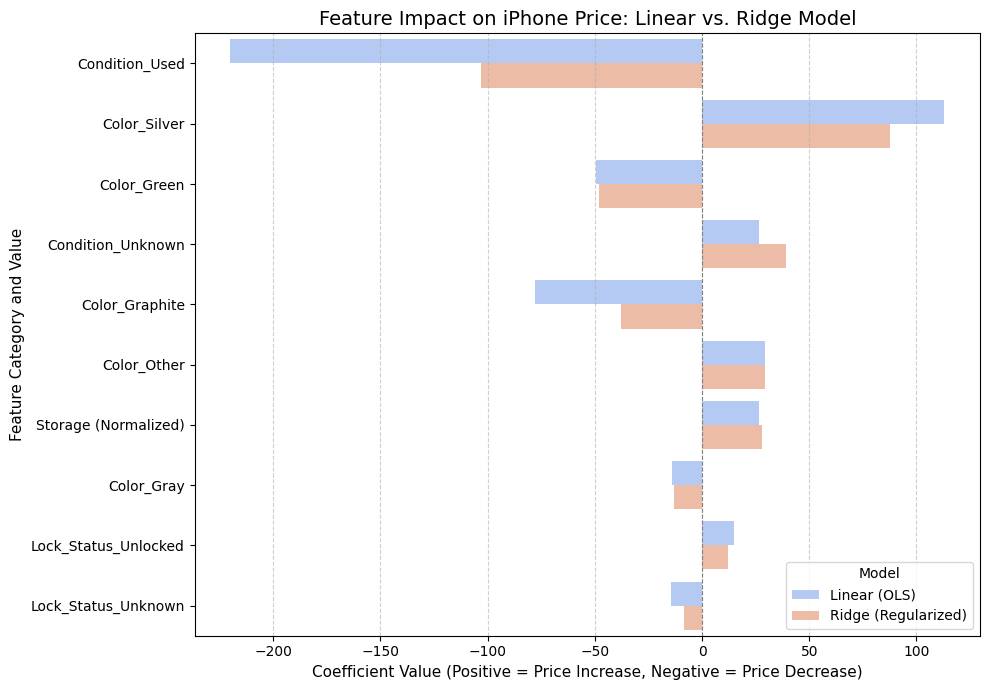

In [72]:
# Block 9: Enhanced Feature Importance Plot

# Helper function to clean up the feature names for better visualization
def clean_feature_name(name):
    # Normalized Storage is the numeric feature
    if name == 'Storage':
        return 'Storage (Normalized)'

    # Handle OneHotEncoded names (e.g., 'color_silver', 'condition_used')
    name = name.replace('color_', 'Color: ')
    name = name.replace('condition_', 'Condition: ')
    name = name.replace('lock_status_', 'Lock: ')

    # Capitalize the value part
    return name.title()

# Get encoded feature names.
encoded_features = list(preprocessor.named_transformers_['cat']
                        .named_steps['encoder'].get_feature_names_out(categorical_features))
all_features = numeric_features + encoded_features

# Extract coefficients
ridge_coeffs = ridge_model.named_steps['regressor'].coef_
linear_coeffs = linear_model.named_steps['regressor'].coef_

# Combine into DataFrame
importance_df = pd.DataFrame({
    'Feature': all_features,
    'Linear (OLS)': linear_coeffs,
    'Ridge (Regularized)': ridge_coeffs
})

# Apply the cleaning function to the feature names
importance_df['Feature'] = importance_df['Feature'].apply(clean_feature_name)

# Sort by Ridge importance (using absolute value) and select the top 15
importance_df = importance_df.sort_values(by='Ridge (Regularized)', key=abs, ascending=False).head(15)

# Plot the results
plt.figure(figsize=(10, 7)) # Increased height for better readability
sns.barplot(data=importance_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient'),
            y='Feature', x='Coefficient', hue='Model', palette='coolwarm')

# Title and labels are made more intuitive
plt.title("Feature Impact on iPhone Price: Linear vs. Ridge Model", fontsize=14)
plt.xlabel("Coefficient Value (Positive = Price Increase, Negative = Price Decrease)", fontsize=11)
plt.ylabel("Feature Category and Value", fontsize=11)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8) # Add zero line for clarity
plt.grid(axis='x', linestyle='--', alpha=0.6) # Grid on X-axis only
plt.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.savefig("feature_importance_plot_enhanced.png")

Predict iPhone 11 Pro Max Price from Custom Inputs

In [71]:
def predict_price(ridge_model):
    """
    Final, robust function to predict price. Uses the fitted ridge_model
    pipeline, handles input case standardization, and uses the correct
    column names to avoid crashes (solving all previous errors).
    """
    print("📱 iPhone 11 Pro Max Price Prediction")
    print("--------------------------------------")

    # --- Feature Extraction Helpers (Matches robust training logic) ---
    def predict_extract_color(c):
        colors = ['gold', 'silver', 'green', 'gray', 'graphite', 'midnight']
        for color in colors:
            # Case-insensitive check
            if color in c.lower():
                return color
        return 'other'

    def predict_extract_condition(c):
        # Case-insensitive check, returns lowercase category
        c_upper = c.upper()
        if 'NEW' in c_upper:
            return 'new'
        elif 'REFURBISHED' in c_upper:
            return 'refurbished'
        elif 'USED' in c_upper:
            return 'used'
        else:
            return 'unknown'

    def predict_extract_lock(l):
        l_lower = l.lower()
        if 'yes' in l_lower or 'unlocked' in l_lower:
            return 'unlocked'
        elif 'no' in l_lower or 'locked' in l_lower:
            return 'locked'
        else:
            return 'unknown'

    # --- Step 1: Take inputs (Use this section in your local environment) ---
    try:
        storage = int(input("Storage (e.g. 64 / 128 / 256 / 512): ").strip())
        condition_input = input("Condition (New / Used / Refurbished): ").strip()
        color_input = input("Color (e.g. Space Gray / Silver / Gold): ").strip()

        # Taking inputs for features NOT used in the model (for user completeness)
        _ = float(input("Battery health percentage (e.g. 85-100): ").strip())
        _ = float(input("Seller rating (e.g. 4.5): ").strip())

        is_unlocked_input = input("Is it unlocked? (Yes / No): ").strip()
        _ = int(input("Age in months (e.g. 12, 18, 24): ").strip())

    except Exception as e:
        print(f"\n--- Input Error: {e}. Please check your input format. ---")
        return

    # --- Step 2: Process inputs into Model-Ready Features (Lowercase) ---
    color_processed = predict_extract_color(color_input)
    condition_processed = predict_extract_condition(condition_input)
    lock_status_processed = predict_extract_lock(is_unlocked_input)

    # --- Step 3: Build DataFrame with **CORRECT CAPITALIZED COLUMN NAMES** ---
    user_input = pd.DataFrame([{
        'Storage': storage,
        'Color': color_processed,
        'Condition': condition_processed,
        'Lock_Status': lock_status_processed
    }])

    # --- Step 4: Predict ---
    predicted_price = ridge_model.predict(user_input)[0]

    # --- Step 5: Output ---
    print("\n💰 Estimated Resale Price:")
    print(f"Your iPhone 11 Pro Max ({storage}GB, {condition_processed.title()}, {color_processed.title()}) ≈ **${predicted_price:.2f}**")


# # You would call this in your local environment after training the model:
predict_price(ridge_model)

📱 iPhone 11 Pro Max Price Prediction
--------------------------------------
Storage (e.g. 64 / 128 / 256 / 512): 512
Condition (New / Used / Refurbished): New
Color (e.g. Space Gray / Silver / Gold): GoLd
Battery health percentage (e.g. 85-100): 100
Seller rating (e.g. 4.5): 5
Is it unlocked? (Yes / No): yes
Age in months (e.g. 12, 18, 24): 1

💰 Estimated Resale Price:
Your iPhone 11 Pro Max (512GB, New, Gold) ≈ **$442.27**
